<a href="https://colab.research.google.com/github/SBekzod/ai_foundation/blob/main/menu_detector_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Menu Detector AI Model


# DataSet 💠 Transformer 💠 DataLoading 💠 FineTuning

In [22]:
print("MENU DETECTOR AI MODEL")

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2

from google.colab import drive
from PIL import Image, UnidentifiedImageError
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np


''' 1 - DEFINE DATASET PATH '''


DATASET_PATH = '/content/drive/MyDrive/food101_dataset'
print('Dataset_path:', DATASET_PATH)

CUSTOM_CLASS_MAPPING = {
    "hamburger": "hamburger",
    "hot_dog": "hot_dog",
    "chocolate_cake": "dessert",  # label grouping | class consolidation
    "cheesecake": "dessert",      # label grouping | class consolidation
    "kebab": "kebab",
    "pilaf": "pilaf"
}


''' 2 - DEFINE LABELS '''


CLASSES = ['hamburger', 'hot_dog', 'dessert', 'kebab', 'pilaf']
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

print("NUM_CLASSES:", NUM_CLASSES)
print("CLASS_TO_IDX:", CLASS_TO_IDX)

# 0 ~ 255 > 0.0 ~ 1.0    H, W, C => C, H, W
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # NormalizedPixel = (pixel - mean) / std
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


''' 3 - CUSTOM DATASET CLASS '''


class FoodDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        # print('images_length', len(self.images))
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        # print('image_path', img_path)
        label = self.labels[idx]
        # print('label', label)
        try:
            image = Image.open(img_path)
            if image.mode == "P" or image.mode == "RGBA":
                image = image.convert("RGBA").convert("RGB")
            else:
                image = image.convert("RGB")
        except (UnidentifiedImageError, OSError):
            print(f"Skipping broken image: {img_path}")
            return self.__getitem__((idx + 1) % len(self.images))

        if self.transform:
            image = self.transform(image)

        return image, label



''' 4 - DEFINE DATASETS INTO TRAIN AND VALIDATION PARTS '''


all_images = []

for original_class, mapped_class in CUSTOM_CLASS_MAPPING.items():
    class_path = os.path.join(DATASET_PATH, original_class)
    # print('class_path:', class_path)

    if not os.path.exists(class_path):
        print(f"Warning: {class_path} not found")
        continue

    for img in os.listdir(class_path):
        if img.endswith(('.jpg', '.jpeg', '.png')):  # .txt, .docx
            full_path = os.path.join(class_path, img)
            all_images.append((full_path, CLASS_TO_IDX[mapped_class]))

np.random.shuffle(all_images) # random tartibga keltirish
split = int(0.8 * len(all_images))
train_data = all_images[:split]
val_data = all_images[split:]

train_images, train_labels = zip(*train_data)
val_images, val_labels = zip(*val_data)

# train_data = [('./kebab3.jpg', 3), ('./cheesecake2.jpg', 2), ('./pilaf1.jpg', 4)]
# train_images = ( './kebab3.jpg','./cheesecake2.jpg', './pilaf1.jpg')
# train_labels = (3, 2, 4)

print('\n all_images:', all_images)

dataset = FoodDataset(train_images, train_labels)
print(len(dataset), "\n")

img, lbl = dataset[0]


train_dataset = FoodDataset(train_images, train_labels, transform=transform)
val_dataset = FoodDataset(val_images, val_labels, transform=transform)
# thread | parallel loading for speed
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)


''' 5 - PRETRAINED MODEL - MobileNetV2 '''


model = mobilenet_v2(weights="IMAGENET1K_V1")  # pretrained model | ligthweight | CNN | 1000 class | million
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)  # fine-tuning | backbone | model layer freeze


''' 6 - DEFINE DEVICE '''


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device', device)
model = model.to(device)


''' 7 - LOSS, WEIGHT AND OPTIMIZED '''


criterion = nn.CrossEntropyLoss() # Loss calculation
optimizer = optim.Adam(model.parameters(), lr=0.001) # Updating weight
torch.backends.cudnn.benchmark = True # Benchmark configuration

print("optimizer:", optimizer)


MENU DETECTOR AI MODEL
Dataset_path: /content/drive/MyDrive/food101_dataset
NUM_CLASSES: 5
CLASS_TO_IDX: {'hamburger': 0, 'hot_dog': 1, 'dessert': 2, 'kebab': 3, 'pilaf': 4}

 all_images: [('/content/drive/MyDrive/food101_dataset/hamburger/423924.jpg', 0), ('/content/drive/MyDrive/food101_dataset/chocolate_cake/3592680.jpg', 2), ('/content/drive/MyDrive/food101_dataset/hamburger/345291.jpg', 0), ('/content/drive/MyDrive/food101_dataset/hamburger/1679008.jpg', 0), ('/content/drive/MyDrive/food101_dataset/hot_dog/2629918.jpg', 1), ('/content/drive/MyDrive/food101_dataset/cheesecake/2363100.jpg', 2), ('/content/drive/MyDrive/food101_dataset/hamburger/292737.jpg', 0), ('/content/drive/MyDrive/food101_dataset/kebab/Image_79.jpg', 3), ('/content/drive/MyDrive/food101_dataset/cheesecake/2438875.jpg', 2), ('/content/drive/MyDrive/food101_dataset/cheesecake/2317205.jpg', 2), ('/content/drive/MyDrive/food101_dataset/cheesecake/2217634.jpg', 2), ('/content/drive/MyDrive/food101_dataset/hamburger/

# **START TRAINING AI MODEL**

In [23]:
''' 8 - TRAINING LOOP & SAVE EFFICIENT AI MODEL  '''

NUM_EPOCHS = 10
best_accuracy = 0.0

for epoch in range(NUM_EPOCHS):
    model.train()  # train model
    running_loss = 0.0

    for images, labels in train_loader:  # Forward and Backward (Backpropagation)
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()  # zero the gradient
        outputs = model(images)  # Forward Pass | Dog | 5 Classes
        loss = criterion(outputs, labels)  # Calculate Loss
        loss.backward()
        optimizer.step()  # Adam optimizer
        running_loss += loss.item()  # Track Loss

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total  # Calculate Validation Accuracy
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Loss: {running_loss/len(train_loader):.4f}, Val Accuracy: {val_acc:.2f}%")

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(model.state_dict(), '/content/menu_detector.pth')
        print("Saved new best model!")

Epoch [1/10] Loss: 0.5125, Val Accuracy: 87.99%
Saved new best model!
Epoch [2/10] Loss: 0.3250, Val Accuracy: 86.33%
Epoch [3/10] Loss: 0.2789, Val Accuracy: 82.40%
Epoch [4/10] Loss: 0.2617, Val Accuracy: 83.71%
Epoch [5/10] Loss: 0.2554, Val Accuracy: 85.26%
Epoch [6/10] Loss: 0.2035, Val Accuracy: 88.82%
Saved new best model!
Epoch [7/10] Loss: 0.1998, Val Accuracy: 90.13%
Saved new best model!
Epoch [8/10] Loss: 0.1605, Val Accuracy: 89.06%
Epoch [9/10] Loss: 0.2398, Val Accuracy: 87.75%
Epoch [10/10] Loss: 0.1638, Val Accuracy: 90.37%
Saved new best model!


# **TEST OUR BEST AI MODEL**

device: cuda
Upload one or more images of hamburger or hot dog:


Saving Image_4.jpg to Image_4 (2).jpg


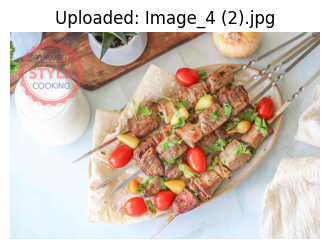

Prediction:
	✅ kebab: 99.99%
	✅ dessert: 0.01%
	✅ hot_dog: 0.00%
	✅ pilaf: 0.00%


In [3]:
import torch
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2
from PIL import Image
from google.colab import files
import io
import matplotlib.pyplot as plt


''' 1 - DEFINE SEMANTIC CLASSES (LABELS) '''


CLASSES = ['hamburger', 'hot_dog', 'dessert', 'kebab', 'pilaf']  # Must match training order
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}


''' 2 - TRANSFORM FOR UPLOADED IMAGES '''


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


''' 3 - LOADING MODEL '''


model = mobilenet_v2(weights=None)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.load_state_dict(torch.load('/content/menu_detector.pth', map_location='cpu'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

model = model.to(device)
model.eval()


''' 4 - UPLOAD TO PREDICT '''


print("Upload one or more images of your food:")
uploaded = files.upload()

for image_name in uploaded.keys():
    image = Image.open(io.BytesIO(uploaded[image_name])).convert('RGB')

    # Display image
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Uploaded: {image_name}')
    plt.show()

    # Predict
    image_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)[0]
        topk = torch.topk(probs, 4)

    print("Prediction:")
    for i in range(topk.indices.size(0)):
        label = CLASSES[topk.indices[i]]
        confidence = topk.values[i].item() * 100
        print(f"\t✅ {label}: {confidence:.2f}%")